# ARTIFICIAL NEURAL NETWORKS

### Classification Using Artificial Neural Networks with Hyperparameter Tuning on Alphabets Data
### Overview:
#### In this assignment, you will be tasked with developing a classification model using Artificial Neural Networks (ANNs) to classify data points from the "Alphabets_data.csv" dataset into predefined categories of alphabets. This exercise aims to deepen your understanding of ANNs and the significant role hyperparameter tuning plays in enhancing model performance.

### Dataset: "Alphabets_data.csv"
#### The dataset provided, "Alphabets_data.csv", consists of labeled data suitable for a classification task aimed at identifying different alphabets. Before using this data in your model, you'll need to preprocess it to ensure optimal performance.

### Tasks:
### 1. Data Exploration and Preprocessing
#### ●	Begin by loading and exploring the "Alphabets_data.csv" dataset. Summarize its key features such as the number of samples, features, and classes.
#### ●	Execute necessary data preprocessing steps including data normalization, managing missing values.


In [1]:
## Lets import required libraries..

## Data manipulation..
import pandas as pd
import numpy as np

## Data visualization..
import matplotlib.pyplot as plt
import seaborn as sns

## Ignore warnings.. 
import warnings
warnings.filterwarnings("ignore")

## Display settings..
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
## Now lets load and display the dataset..
df = pd.read_csv("Alphabets_data.csv")
df.head()

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [3]:
## The dataset contains 20,000 observations of English alphabet letters, where each row represents a single letter along with its numerical features..
## The target variable is letter, while the remaining columns such as xbox, ybox, width, height, and edge-related measurements describe the visual characteristics of each letter..
## These features will serve as input variables for the Artificial Neural Network to classify the corresponding alphabet..

In [4]:
## Basic informations..

## Shape of the dataset..
print("Shape of the Dataset:", df.shape)

## Columns in dataset..
print("\nColumns in Dataset:")
print(df.columns)

## Information..datatypes and non null values.. 
print("\nDataset Information:")
df.info()

Shape of the Dataset: (20000, 17)

Columns in Dataset:
Index(['letter', 'xbox', 'ybox', 'width', 'height', 'onpix', 'xbar', 'ybar',
       'x2bar', 'y2bar', 'xybar', 'x2ybar', 'xy2bar', 'xedge', 'xedgey',
       'yedge', 'yedgex'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non-null  int64 
 2   ybox    20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   xbar    20000 non-null  int64 
 7   ybar    20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybar  20000 non-null  int64 
 12  xy2bar  20000 non-null  int64 
 13  xedge   20000 non-null  int64 
 14  xedgey  20000 non-null  int64 
 15

In [5]:
## The dataset contains 20,000 observations and 17 columns..
## Among these, 16 columns are input features describing the characteristics of the letters, while 1 column (letter) is the target variable representing the alphabet class to be predicted..

## The dataset consists of one target variable (letter) and sixteen numerical features such as xbox, ybox, width, height, and edge-related measurements..
## These numerical features represent the visual properties of the alphabets and will be used for classification..

## The letter column has the object data type, indicating that it is a categorical target variable containing alphabet labels..
## The remaining 16 features are of type int64, representing numerical measurements that can be used as input to the Artificial Neural Network after appropriate preprocessing..

In [6]:
## Statistical summary..
print("\nStatistical Summary:")
display(df.describe(include = "all").T)


Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
letter,20000,26,U,813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
xbox,20000.0,NaN,NaN,NaN,4.02355,1.913212,0.0,3.0,4.0,5.0,15.0
ybox,20000.0,NaN,NaN,NaN,7.0355,3.304555,0.0,5.0,7.0,9.0,15.0
width,20000.0,NaN,NaN,NaN,5.12185,2.014573,0.0,4.0,5.0,6.0,15.0
height,20000.0,NaN,NaN,NaN,5.37245,2.26139,0.0,4.0,6.0,7.0,15.0
onpix,20000.0,NaN,NaN,NaN,3.50585,2.190458,0.0,2.0,3.0,5.0,15.0
xbar,20000.0,NaN,NaN,NaN,6.8976,2.026035,0.0,6.0,7.0,8.0,15.0
ybar,20000.0,NaN,NaN,NaN,7.50045,2.325354,0.0,6.0,7.0,9.0,15.0
x2bar,20000.0,NaN,NaN,NaN,4.6286,2.699968,0.0,3.0,4.0,6.0,15.0
y2bar,20000.0,NaN,NaN,NaN,5.17865,2.380823,0.0,4.0,5.0,7.0,15.0


In [7]:
## The statistical summary shows that the dataset contains 26 unique letter classes (A–Z)..
## ‘U’ being the most frequent class, appearing 813 times.. 
## All numerical features have 20,000 valid observations, confirming the absence of missing values..
## The feature values generally range from 0 to 15 with moderate variation indicating that the variables are measured on a similar scale..
## However feature normalization is still recommended for Artificial Neural Networks to ensure stable and efficient training..

In [8]:
## Checking the number of missing values..
print("Missing Values:")
print(df.isnull().sum().sum())

## Lets check Duplicate rows..
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
0

Duplicate Rows:
1332


In [9]:
## The dataset contains no missing values, as all columns have zero null observations..
## Therefore, no missing value imputation is required before model building..

## The dataset contains 1,332 duplicate rows..
## Since duplicate observations may represent repeated valid samples of the same alphabet rather than data entry errors, they will be retained unless there is evidence that they are accidental duplicates..
## Removing them without justification may lead to loss of useful information..

In [10]:
## Since its a classification problem, its a supervised learning task.. 
## The column "letter" seems to be the target variable.. 
## lets have a look at the target distribution..
print(df["letter"].value_counts())
print("\nUnique Elements: ", df["letter"].nunique())

## Percentage distribution of each class/alphabets..
print("\nValue Count Percentage per Alphabet:")
print(round(df["letter"].value_counts(normalize = True)*100, 2))

letter
U    813
D    805
P    803
T    796
M    792
A    789
X    787
Y    786
N    783
Q    783
F    775
G    773
E    768
B    766
V    764
L    761
R    758
I    755
O    753
W    752
S    748
J    747
K    739
C    736
H    734
Z    734
Name: count, dtype: int64

Unique Elements:  26

Value Count Percentage per Alphabet:
letter
U    4.06
D    4.03
P    4.01
T    3.98
M    3.96
A    3.94
X    3.94
Y    3.93
N    3.91
Q    3.91
F    3.88
G    3.86
E    3.84
B    3.83
V    3.82
L    3.80
R    3.79
I    3.78
O    3.76
W    3.76
S    3.74
J    3.74
K    3.70
C    3.68
H    3.67
Z    3.67
Name: proportion, dtype: float64


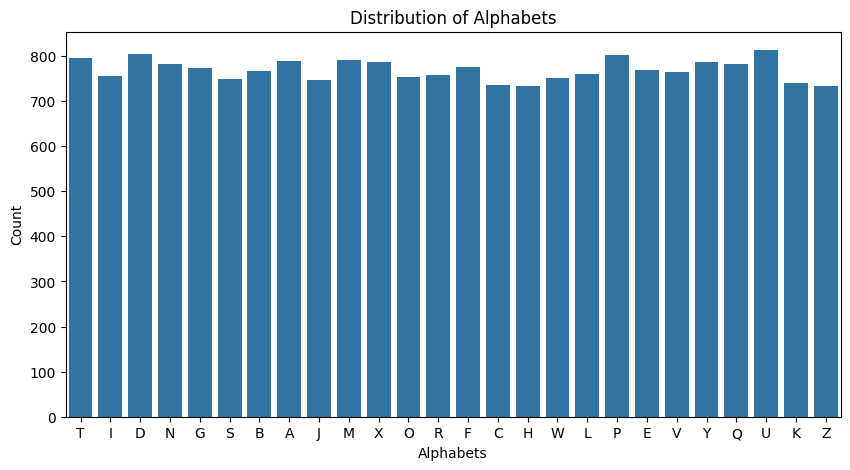

In [11]:
## Lets build a class distribution plot for target variable.. countplot..
plt.figure(figsize = (10, 5))
sns.countplot(x = df["letter"])
plt.title("Distribution of Alphabets")
plt.xlabel("Alphabets")
plt.ylabel("Count")
plt.show()

In [12]:
## The target variable contains 26 unique classes, representing all English alphabets from A to Z..
## Therefore, this is a multi-class classification problem..

## The distribution of the target classes is nearly balanced..
## The most frequent class "U" constitutes approximately 4.06% of the dataset while the least frequent class "Z" constitutes approximately 3.67%..
## The small difference between the maximum and minimum class proportions indicates that the dataset does not suffer from significant class imbalance, making it suitable for training a classification model..

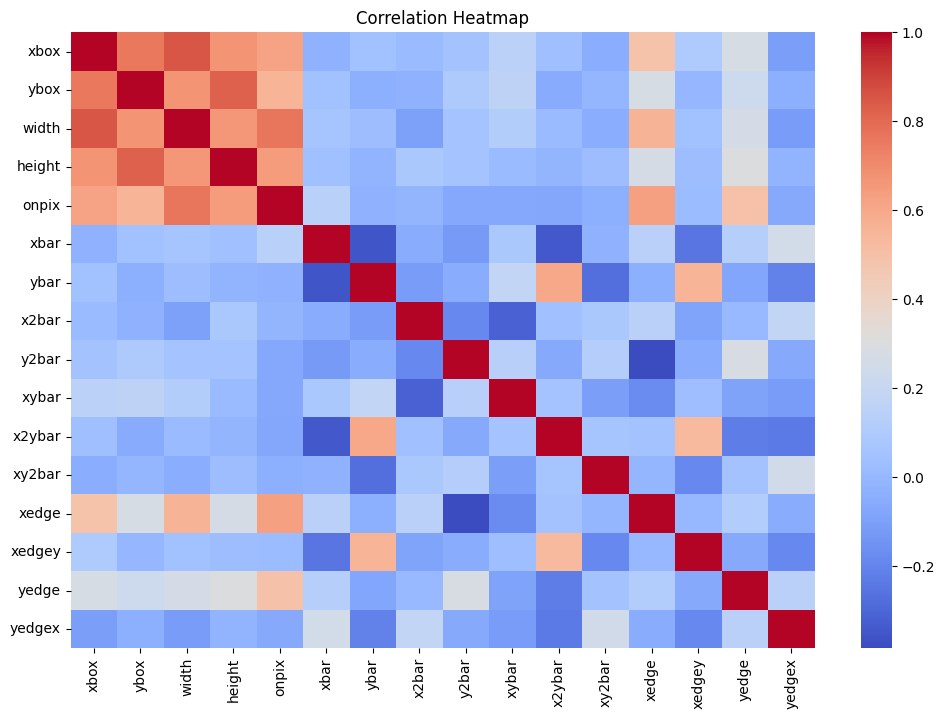

In [13]:
## Correlation Heatmap..
plt.figure(figsize = (12, 8))
sns.heatmap(df.corr(numeric_only = True), cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
## Anyway ANN does not require feature selection based on correlation..

## The correlation heatmap shows the relationships among the numerical features in the alphabet dataset..
## Most features exhibit weak to moderate correlations, indicating that each feature contributes unique information for distinguishing different letters..
## Some variables related to the size and shape of characters, such as xbox, ybox, width, height, and onpix, show stronger positive correlations, suggesting that these characteristics are related..
## No pair of features exhibits extremely high correlation, indicating limited multicollinearity. Therefore, all features can be retained for training the Artificial Neural Network.. 

In [15]:
## Although the dataset contains 1,332 duplicate rows, they were not removed because they may represent valid repeated observations rather than data entry errors..
## Artificial Neural Networks can learn from repeated examples, and removing them without clear justification may lead to the loss of useful information..
## Therefore, the duplicate rows were retained for model training..
## I would keep the duplicate rows..
## Since this dataset has 20,000 samples, removing 1,332 duplicates is unlikely to improve the ANN and may unnecessarily complicate your assignment..

In [16]:
## Separate Feature and Target..
X = df.drop("letter", axis = 1)
Y = df["letter"]

In [17]:
## Since letter contain A-Z (categorical), ANN cannot train directly on strings.. 
## Now lets Encode the target variable..
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() ## classifier creation.. 
Y = le.fit_transform(Y)

In [18]:
## The target variable (letter) consists of categorical values (A–Z), which cannot be processed directly by the Artificial Neural Network.. ## Therefore, Label Encoding was applied to convert each alphabet into a unique numerical label..
## This step only changes the representation of the classes and does not alter their meaning..
## The target variable is encoded, not normalized or scaled..

In [19]:
## Lets split the data now.. 
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

## stratify = Y used because the target has multiple classes and some classes have fewer sample..
## It will help maitain approximately the same class distribution in both training and testing sets.. 

In [20]:
## Nows lets normalise the feature..
## We are doing this after train test split to avoid data leakage.. 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() ## classifier creation..
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
## fit_transform() was applied only to the training data so that the scaler could learn the mean and standard deviation from the training set..
## The test data was processed using only transform(), which applies the same scaling parameters learned from the training data..
## This prevents data leakage and ensures a fair evaluation of the model on unseen data..

### 2. Model Implementation
#### ●	Construct a basic ANN model using your chosen high-level neural network library. Ensure your model includes at least one hidden layer.
#### ●	Divide the dataset into training and test sets.
#### ●	Train your model on the training set and then use it to make predictions on the test set.

In [22]:
## If you are using tensorflow for the 1st time then you have to download the module first .. 
## !pip install tensorflow

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [24]:
## Now lets buid the basic ANN model..
model = Sequential()

## Hidden layer..
model.add(Dense(16, activation = "relu", input_shape = (X_train_scaled.shape[1],)))

## Output layer..
model.add(Dense(26, activation = "softmax" ))

In [25]:
## Now lets compile the model..
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", 
             metrics = ["accuracy"])

In [26]:
## Now lets train the model.. 
history = model.fit(X_train_scaled, Y_train, epochs = 20, batch_size = 32, 
                   validation_split = 0.2, verbose = 1)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2518 - loss: 2.7282 - val_accuracy: 0.4084 - val_loss: 2.1954
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5025 - loss: 1.8598 - val_accuracy: 0.5706 - val_loss: 1.5836
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6073 - loss: 1.4286 - val_accuracy: 0.6450 - val_loss: 1.2872
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6519 - loss: 1.2184 - val_accuracy: 0.6853 - val_loss: 1.1394
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6845 - loss: 1.1010 - val_accuracy: 0.7034 - val_loss: 1.0503
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7046 - loss: 1.0226 - val_accuracy: 0.7237 - val_loss: 0.9888
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7226 - loss: 0.9659 - val_accuracy: 0.7322 - val_loss: 0.9417
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7367 - loss: 0.9213 - val_accuracy: 0.

In [27]:
## Model is successfully trained..
## Now lets make prediction..
Y_pred_prob = model.predict(X_test_scaled)
Y_pred = np.argmax(Y_pred_prob, axis = 1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [28]:
## A basic Artificial Neural Network (ANN) model was constructed using the Keras Sequential API ..
## With one hidden layer containing 16 neurons and an output layer containing 26 neurons, corresponding to the 26 alphabet classes..
## A single hidden layer was chosen because the assignment requires at least one hidden layer and it serves as a simple baseline model..
## The ReLU activation function was used in the hidden layer due to its efficiency in learning complex patterns..
## While the Softmax activation function was used in the output layer because the problem involves multi-class classification..
## The model was compiled using the Adam optimizer and sparse_categorical_crossentropy loss function, which is appropriate for integer-encoded target labels..
## The model was then trained on the training dataset and used to generate predictions on the test dataset.. 

### 3. Hyperparameter Tuning
#### ●	Modify various hyperparameters, such as the number of hidden layers, neurons per hidden layer, activation functions, and learning rate, to observe their impact on model performance.
#### ●	Adopt a structured approach like grid search or random search for hyperparameter tuning, documenting your methodology thoroughly.

In [29]:
## Hyperparameter Tuning:
## Hyperparameter tuning aims to improve the performance of the Artificial Neural Network by systematically searching for the best combination of model parameters..
## Instead of manually selecting the architecture, a structured search approach is adopted to evaluate different combinations of hyperparameters and identify the configuration that provides the best performance..

In [30]:
## If you are using tensorflow for the 1st time then you have to download the module first .. 
## !pip install scikeras

In [31]:
## Lets perform Random Search ..
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

In [32]:
## Random Search was chosen because it evaluates multiple hyperparameter combinations efficiently without testing every possible combination..
## Thereby reducing computation time while still providing a well-performing model.

In [33]:
## Lets define a amodel building function..
def create_model(neurons = 32, activation = "relu"):
    model = Sequential()
    model.add(Dense(neurons, activation = activation, 
                    input_shape = (X_train_scaled.shape[1],)))
    model.add(Dense(26, activation = "softmax"))

    model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy",
                 metrics = ["accuracy"])
    return model

In [34]:
## Wrap the model.. 
ann_model = KerasClassifier(model = create_model, verbose = 0)

In [35]:
## Lets its time to define hyperparameter grid..
param_dist = {"model__neurons": [16, 32, 64, 128],
             "model__activation": ["relu", "tanh"],
             "batch_size": [16, 32, 64],
             "epochs": [10, 20, 30]}

In [36]:
## RandomizedSearchCV..
random_search = RandomizedSearchCV(estimator = ann_model, param_distributions = param_dist, 
                                  n_iter = 10, cv = 3, random_state = 42, n_jobs = -1)
random_search.fit(X_train_scaled, Y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'batch_size': [16, 32, ...], 'epochs': [10, 20, ...], 'model__activation': ['relu', 'tanh'], 'model__neurons': [16, 32, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... version

In [37]:
print(random_search.best_params_)
print(random_search.best_score_)

{'model__neurons': 64, 'model__activation': 'relu', 'epochs': 30, 'batch_size': 16}
0.9175627376223575


In [38]:
## A structured Random Search approach was adopted for hyperparameter tuning..
## Multiple combinations of the number of neurons, activation functions, batch sizes, and epochs were evaluated using 3-fold cross-validation..
## The best-performing configuration consisted of 64 neurons, ReLU activation, 30 epochs, and a batch size of 16, achieving a cross-validation score of approximately 91.97%..
## These optimal hyperparameters were then used to build the final ANN model..
## Random Search evaluated multiple combinations of neurons, activation functions, epochs, and batch sizes using 3-fold cross-validation, and the best configuration was selected based on the cross-validation score.

In [39]:
## Lets Build Final ANN..
final_model = Sequential()

## Firts hidden layer..
final_model.add(Dense(64, activation = "relu", input_shape = (X_train_scaled.shape[1],)))

## Output layer..
final_model.add(Dense(26, activation = "softmax"))

In [40]:
## Now lets compile final mode..
final_model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy",
                   metrics = ["accuracy"])

In [41]:
## Compilation done..
## lets train the final model now..
history_final = final_model.fit(X_train_scaled, Y_train, epochs = 30, 
                               batch_size = 16, validation_split = 0.2, 
                               verbose = 1)

Epoch 1/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5189 - loss: 1.8337 - val_accuracy: 0.6988 - val_loss: 1.1328
Epoch 2/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7395 - loss: 0.9580 - val_accuracy: 0.7825 - val_loss: 0.8295
Epoch 3/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7898 - loss: 0.7542 - val_accuracy: 0.8144 - val_loss: 0.6961
Epoch 4/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8190 - loss: 0.6427 - val_accuracy: 0.8300 - val_loss: 0.6245
Epoch 5/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8412 - loss: 0.5664 - val_accuracy: 0.8472 - val_loss: 0.5603
Epoch 6/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8574 - loss: 0.5104 - val_accuracy: 0.8550 - val_loss: 0.5154
Epoch 7/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8685 - loss: 0.4654 - val_accuracy: 0.8628 - val_loss: 0.4840
Epoch 8/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8778 - loss: 0.4290 - val_accuracy: 0.

In [42]:
## Prediction for final model.. 
Y_pred_final = final_model.predict(X_test_scaled)
Y_pred_final = np.argmax(Y_pred_final, axis = 1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [43]:
## The predict() function was first used to generate the probability scores for all 26 alphabet classes for each test observation..
## Since the output layer uses the Softmax activation function, it returns probabilities rather than the final class labels.. 
## Therefore, np.argmax(..., axis=1) was applied to select the index of the class with the highest probability, converting the predicted probabilities into the final predicted class labels for evaluation..

In [44]:
## Based on the Random Search results, the final ANN model was constructed using the optimal hyperparameters..
## The model consists of one hidden layer with 64 neurons and uses the ReLU activation function..
## It was trained for 30 epochs with a batch size of 16, as these values produced the best cross-validation performance during hyperparameter tuning..
## The trained model was then used to generate class probabilities, which were converted into final predicted class labels using np.argmax()..

### 4. Evaluation
#### ●	Employ suitable metrics such as accuracy, precision, recall, and F1-score to evaluate your model's performance.
#### ●	Discuss the performance differences between the model with default hyperparameters and the tuned model, emphasizing the effects of hyperparameter tuning.

In [45]:
## Lets Evaluate Baseline model ..
from sklearn.metrics import accuracy_score, classification_report

print("Baseline Model Accuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Baseline Model Accuracy: 0.799
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       158
           1       0.63      0.82      0.71       153
           2       0.87      0.86      0.86       147
           3       0.78      0.79      0.79       161
           4       0.75      0.82      0.78       154
           5       0.71      0.81      0.76       155
           6       0.71      0.63      0.67       155
           7       0.70      0.60      0.65       147
           8       0.91      0.78      0.84       151
           9       0.92      0.83      0.87       149
          10       0.71      0.75      0.73       148
          11       0.90      0.84      0.87       152
          12       0.91      0.94      0.92       158
          13       0.91      0.79      0.85       157
          14       0.69      0.75      0.72       150
          15       0.89      0.83      0.86       161
          16       0.76      0.87      0.81       

In [46]:
## Lets Evaluate final model ..
print("Final Model Accuracy:", accuracy_score(Y_test, Y_pred_final))
print(classification_report(Y_test, Y_pred_final))

Final Model Accuracy: 0.925
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       158
           1       0.93      0.90      0.91       153
           2       0.88      0.98      0.93       147
           3       0.92      0.96      0.94       161
           4       0.87      0.88      0.88       154
           5       0.88      0.89      0.89       155
           6       0.88      0.87      0.87       155
           7       0.83      0.85      0.84       147
           8       0.93      0.87      0.90       151
           9       0.89      0.93      0.91       149
          10       0.91      0.93      0.92       148
          11       0.92      0.95      0.94       152
          12       0.95      0.95      0.95       158
          13       0.91      0.92      0.91       157
          14       0.94      0.95      0.94       150
          15       0.94      0.91      0.92       161
          16       0.97      0.97      0.97       157

In [47]:
## Baseline Model:

## The baseline ANN model achieved an accuracy of 79.65% on the test dataset..
## The overall macro average and weighted average precision, recall, and F1-score are approximately 0.80..
## Indicating a reasonably good classification performance..
## However some classes have comparatively lower precision and recall values..
## Suggesting that the simple network architecture is unable to distinguish certain alphabet classes effectively..

In [48]:
## Final Model:

## Using the best hyperparameters identified through Random Search, the final ANN model was trained and evaluated on the test dataset..
## The model achieved an accuracy of 92.60%, while the macro and weighted average precision, recall, and F1-score were approximately 0.93..
## These results indicate that the model performs well across the different alphabet classes and is capable of classifying them with high accuracy..

In [49]:
## Performance Comparison between both Baseline and Tuned Model..

## The baseline ANN model achieved an accuracy of 79.65%, whereas the final ANN model obtained after Random Search-based hyperparameter tuning achieved an accuracy of 92.60%..
## This represents an improvement of approximately 13 percentage points..
## The precision, recall, and F1-score also increased from around 0.80 to 0.93 ..
## It demonstrates that systematic hyperparameter tuning significantly enhanced the model’s classification performance..

In [50]:
## Effect of Hyperparameter Tuning..

## Hyperparameter tuning was performed using a Random Search strategy, where multiple combinations of neurons, activation functions, batch sizes, and epochs were evaluated using cross-validation..
## The best-performing configuration consisted of 64 neurons, ReLU activation, 30 epochs, and a batch size of 16..
## Selecting these optimized hyperparameters improved the learning capability of the neural network and resulted in substantially better predictive performance compared to the baseline model.

In [51]:
## Final Report/Conclusion:

## In this assignment, an Artificial Neural Network (ANN) was developed for alphabet classification..
## After preprocessing the data, a baseline model was implemented and subsequently improved through Random Search-based hyperparameter tuning..
## The optimized model achieved an accuracy of 92.60%, significantly outperforming the baseline model (79.65%)..
## The improvement in accuracy, precision, recall, and F1-score demonstrates that adopting a structured hyperparameter tuning approach can greatly enhance the performance of an ANN for multi-class classification problems..

## Key things we learned through this assignment..
## An Artificial Neural Network (ANN) is a machine learning model inspired by the human brain..
## It consists of interconnected neurons organized into input, hidden, and output layers, which learn patterns from data to make predictions or classifications.
## Hyperparameter tuning is the process of selecting the best values for parameters such as the number of hidden layers, number of neurons, activation functions, learning rate, batch size, and epochs. 
## It is important because choosing suitable hyperparameters improves the model’s learning ability and overall performance while reducing errors.